<a href="https://colab.research.google.com/github/Kashishkewat/python_practice/blob/main/day36_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Bagging Ensemble (Bootstrap Aggregating)**

**You already explored voting ensembles and logistic/ridge/lasso, so think of bagging as another way to combine models — but instead of different algorithms, it trains the same model many times on different sampled datasets and then combines their predictions.**

In [1]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
iris_data = load_iris()
df = pd.DataFrame(iris_data.data, columns=iris_data.feature_names)
df['species'] = iris_data.target

In [12]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [13]:
df=df[df["species"]!=0][["sepal length (cm)","petal length (cm)","species"]]

In [14]:
df.head()

,sepal length (cm),petal length (cm),species
50,7.0,4.7,1
51,6.4,4.5,1
52,6.9,4.9,1
53,5.5,4.0,1
54,6.5,4.6,1


In [8]:
import seaborn as sns

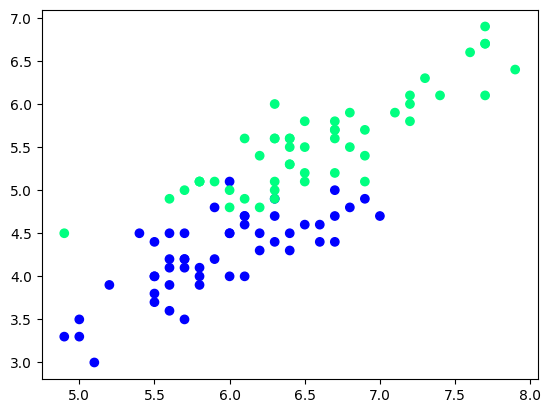

In [16]:
plt.scatter(df["sepal length (cm)"],df["petal length (cm)"],c=df["species"],cmap='winter')

In [17]:
df=df.sample(100)
df_train=df.iloc[:60,:].sample(10)
df_val=df.iloc[60:80,:].sample(5)
df_test=df.iloc[80:,:].sample(5)

In [18]:
df_train

,sepal length (cm),petal length (cm),species
120,6.9,5.7,2
125,7.2,6.0,2
69,5.6,3.9,1
108,6.7,5.8,2
96,5.7,4.2,1
126,6.2,4.8,2
93,5.0,3.3,1
101,5.8,5.1,2
106,4.9,4.5,2
135,7.7,6.1,2


In [19]:
X_test=df_val.iloc[:,0:2].values
y_test=df_val.iloc[:,-1].values

# **Case 1 - Bagging**

In [20]:
# data for Tree 1
df_bag=df_train.sample(8,replace=True)
X=df_bag.iloc[:,0:2].values
y=df_bag.iloc[:,-1].values
df_bag

,sepal length (cm),petal length (cm),species
126,6.2,4.8,2
69,5.6,3.9,1
96,5.7,4.2,1
106,4.9,4.5,2
108,6.7,5.8,2
120,6.9,5.7,2
106,4.9,4.5,2
101,5.8,5.1,2


In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions

In [23]:
dt_bag1=DecisionTreeClassifier()

In [27]:
def evaluate(clf,X,y):
  clf.fit(X,y)
  plot_tree(clf)
  plt.show()
  plot_decision_regions(X,y,clf=clf,legend=2)
  y_pred=clf.predict(X_test)
  print(accuracy_score(y_test,y_pred))
#

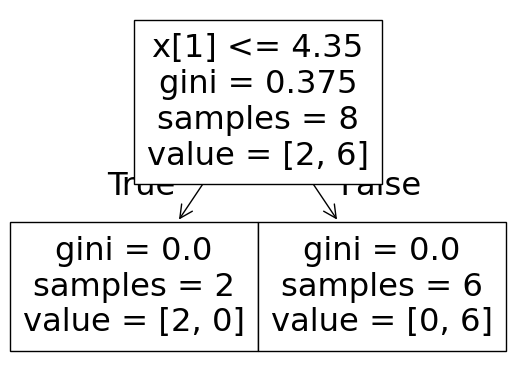

0.6


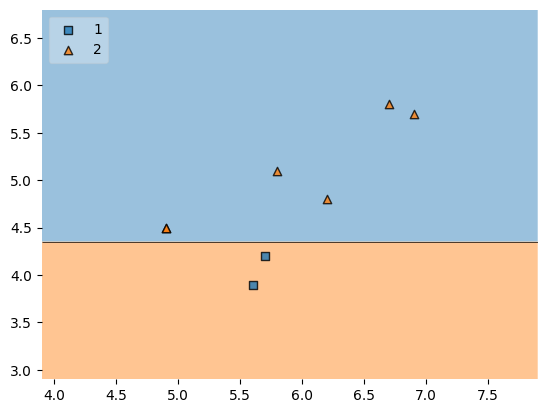

In [28]:
evaluate(dt_bag1,X,y)
#

In [29]:
# data for Tree 1
df_bag=df_train.sample(8,replace=True)
X=df_bag.iloc[:,0:2].values
y=df_bag.iloc[:,-1].values
df_bag

,sepal length (cm),petal length (cm),species
126,6.2,4.8,2
135,7.7,6.1,2
108,6.7,5.8,2
101,5.8,5.1,2
126,6.2,4.8,2
125,7.2,6.0,2
126,6.2,4.8,2
125,7.2,6.0,2


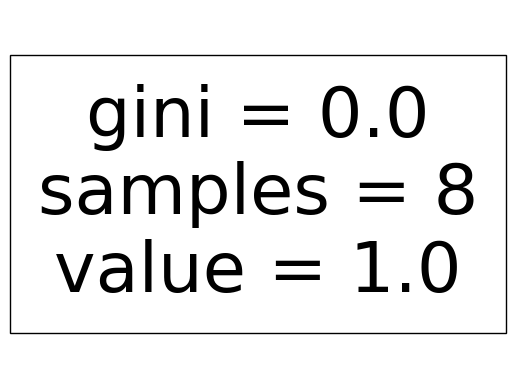

0.4


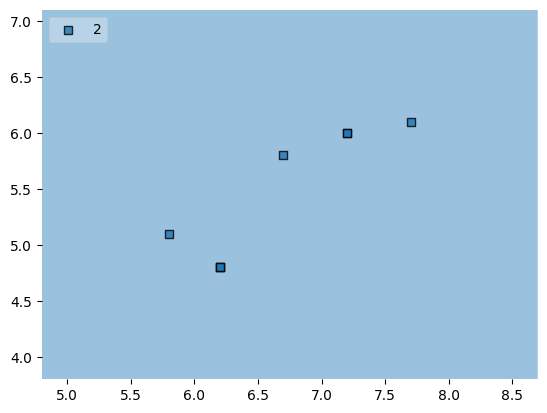

In [30]:
dt_bag2=DecisionTreeClassifier()
evaluate(dt_bag2,X,y)


In [31]:
# data for Tree 1
df_bag=df_train.sample(8,replace=True)
X=df_bag.iloc[:,0:2].values
y=df_bag.iloc[:,-1].values
df_bag

,sepal length (cm),petal length (cm),species
106,4.9,4.5,2
93,5.0,3.3,1
106,4.9,4.5,2
125,7.2,6.0,2
126,6.2,4.8,2
93,5.0,3.3,1
96,5.7,4.2,1
108,6.7,5.8,2


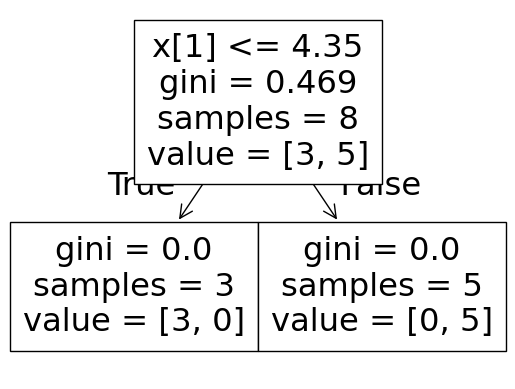

0.6


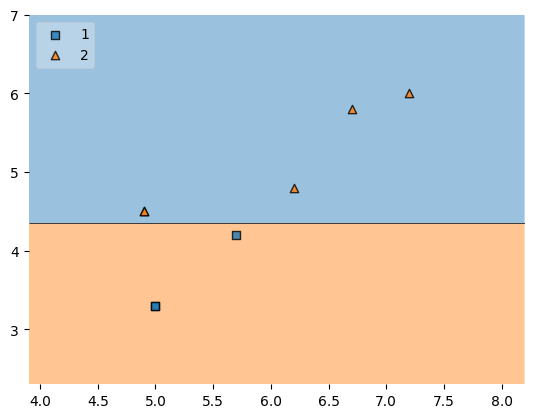

In [32]:
dt_bag3=DecisionTreeClassifier()
evaluate(dt_bag3,X,y)


# **predict**

In [33]:
df_test

,sepal length (cm),petal length (cm),species
143,6.8,5.9,2
89,5.5,4.0,1
100,6.3,6.0,2
134,6.1,5.6,2
102,7.1,5.9,2


In [51]:
print("predictor 1",dt_bag1.predict(np.array([5.5,4.0]).reshape(1,2)))
print("predictor 2",dt_bag2.predict(np.array([5.5,4.0]).reshape(1,2)))
print("predictor 3",dt_bag3.predict(np.array([5.5,4.0]).reshape(1,2)))

predictor 1 [1]
predictor 2 [2]
predictor 3 [1]


# **Pasting**

In [39]:
df_train

,sepal length (cm),petal length (cm),species
120,6.9,5.7,2
125,7.2,6.0,2
69,5.6,3.9,1
108,6.7,5.8,2
96,5.7,4.2,1
126,6.2,4.8,2
93,5.0,3.3,1
101,5.8,5.1,2
106,4.9,4.5,2
135,7.7,6.1,2


In [40]:
df_train.sample(8)

,sepal length (cm),petal length (cm),species
126,6.2,4.8,2
125,7.2,6.0,2
106,4.9,4.5,2
135,7.7,6.1,2
96,5.7,4.2,1
69,5.6,3.9,1
120,6.9,5.7,2
93,5.0,3.3,1


# **Random Subspaces**

In [48]:
iris_data=load_iris()
df1=pd.DataFrame(iris_data.data,columns=iris_data.feature_names)
df1['species']=iris_data.target

In [49]:
df1

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [59]:
df1.sample(2,replace=True,axis=1)

,petal width (cm),petal length (cm)
0,0.2,1.4
1,0.2,1.4
2,0.2,1.3
3,0.2,1.5
4,0.2,1.4
...,...,...
145,2.3,5.2
146,1.9,5.0
147,2.0,5.2
148,2.3,5.4


# **Random Patches**

In [60]:
df1

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [61]:
df1.sample(8,replace=True).sample(2,axis=1,replace=True)

,petal width (cm),sepal width (cm)
1,0.2,3.0
86,1.5,3.1
127,1.8,3.0
40,0.3,3.5
35,0.2,3.2
61,1.5,3.0
30,0.2,3.1
37,0.1,3.6
